### Step 1: Download Data

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set()
sns.set_style('darkgrid')


import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats as sms

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf

from statsmodels.tsa.arima.model import ARIMA

In [2]:
ticker1 = '^NSEI'
start1 = '2019-01-01'
data = yf.download(ticker1, start=start1, auto_adjust=False)

desired_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close']

data = data[[col for col in desired_columns if col in data.columns]]
data.columns = data.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Open,High,Low,Close,Adj Close
Date,,,,,
2019-01-02,10868.849609,10895.349609,10735.049805,10792.500000,10792.500000
2019-01-03,10796.799805,10814.049805,10661.250000,10672.250000,10672.250000
2019-01-04,10699.700195,10741.049805,10628.650391,10727.349609,10727.349609
2019-01-07,10804.849609,10835.950195,10750.150391,10771.799805,10771.799805
2019-01-08,10786.250000,10818.450195,10733.250000,10802.150391,10802.150391


### Step 2: Convert to weekly Data

In [4]:
data_w = data.resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Adj Close': 'last'
})

data_w['returns'] = data_w['Adj Close'].pct_change()
data_w = data_w.dropna()

In [5]:
data_w.head()

Price,Open,High,Low,Close,Adj Close,returns
Date,,,,,,
2019-01-13,10804.849609,10870.400391,10733.250000,10794.950195,10794.950195,0.006302
2019-01-20,10807.000000,10930.650391,10692.349609,10906.950195,10906.950195,0.010375
2019-01-27,10919.349609,10987.450195,10756.450195,10780.549805,10780.549805,-0.011589
2019-02-03,10792.450195,10983.450195,10583.650391,10893.650391,10893.650391,0.010491
2019-02-10,10876.750000,11118.099609,10814.150391,10943.599609,10943.599609,0.004585


In [6]:
print(f'Date Range: {data_w.index[0].date()} to {data_w.index[-1].date()}')

Date Range: 2019-01-13 to 2026-03-22


### Step 3: Check Stationarity

In [7]:
# Check if our returns are stationary

def check_stationarity_quick(the_series):

    from statsmodels.tsa.stattools import adfuller

    result = adfuller(the_series.dropna())

    print(f'p-value = {result[1]:.5f}')

In [8]:
check_stationarity_quick(data_w['Adj Close'])

p-value = 0.76351


In [9]:
check_stationarity_quick(data_w['returns'])

p-value = 0.00000


### Step 4: AR Strategy

In [10]:
def create_ar_strategy(data, train_window=100):

    results=[]

    for i in range(train_window, len(data)):
        if i % 100 == 0:
            print(f'Processed {i}/{len(data)}')
        train_series = (data.iloc[i-train_window:i])

        # Fit AR(1) model (ARIMA with order (1,0,0))
        init_model = ARIMA(train_series, order=(1,0,0))
        fitted_model = init_model.fit()

        # Make one step ahead forecast
        forecast = fitted_model.forecast(steps=1)[0]

        # Store result

        results.append({
            'date': data.index[i],
            'actual_returns': data.iloc[i],
            'predicted_returns': forecast,
            'signal': 1 if forecast > 0 else -1
        })

    return pd.DataFrame(results).set_index('date')
        
            

In [11]:
ar_strategy = create_ar_strategy(data_w['returns'])

Processed 100/376
Processed 200/376
Processed 300/376


In [12]:
# Calculate Strategy Returns

ar_strategy['strategy_returns'] = ar_strategy['signal'].shift(1) * ar_strategy['actual_returns']

In [13]:
print(ar_strategy[['actual_returns', 'predicted_returns', 'signal']].head(10).round(4))

            actual_returns  predicted_returns  signal
date                                                 
2020-12-13          0.0193             0.0041       1
2020-12-20          0.0183             0.0040       1
2020-12-27         -0.0008             0.0041       1
2021-01-03          0.0196             0.0026       1
2021-01-10          0.0235             0.0044       1
2021-01-17          0.0060             0.0049       1
2021-01-24         -0.0043             0.0037       1
2021-01-31         -0.0513             0.0027       1
2021-02-07          0.0946            -0.0022      -1
2021-02-14          0.0160             0.0067       1


In [14]:
# Calculate Performance Metrics

def calculate_performance(strategy_returns, actual_returns, strategy_name='Strategy'):

    # Remove NaN values

    strat_ret = strategy_returns.dropna()
    actual_ret = actual_returns.dropna()

    # Win rate
    win_rate = (strat_ret > 0).mean()
    # Align the series
    common_dates = strat_ret.index.intersection(actual_ret.index)
    strat_ret = strat_ret[common_dates]
    actual_ret = actual_ret[common_dates]

    # Calculate Metrics

    total_strategy = (1 + strat_ret).cumprod().iloc[-1] - 1
    total_buyhold = (1 + actual_ret).cumprod().iloc[-1] - 1

    print(f'Total returns (Strategy): {total_strategy:.2%}')
    print(f'Total returns (buy & hold): {total_buyhold:.2%}')
    print(f'Win Rate: {win_rate:.1%}')

    return {
        'strategy_return': total_strategy,
        'buyhold_returns': total_buyhold,
        'win_rate': win_rate
    }

In [15]:
calculate_performance(ar_strategy['strategy_returns'], ar_strategy['actual_returns'], "AR(1) Model")

Total returns (Strategy): 65.41%
Total returns (buy & hold): 71.04%
Win Rate: 56.0%


{'strategy_return': np.float64(0.6540993814804934),
 'buyhold_returns': np.float64(0.7104304597236888),
 'win_rate': np.float64(0.56)}

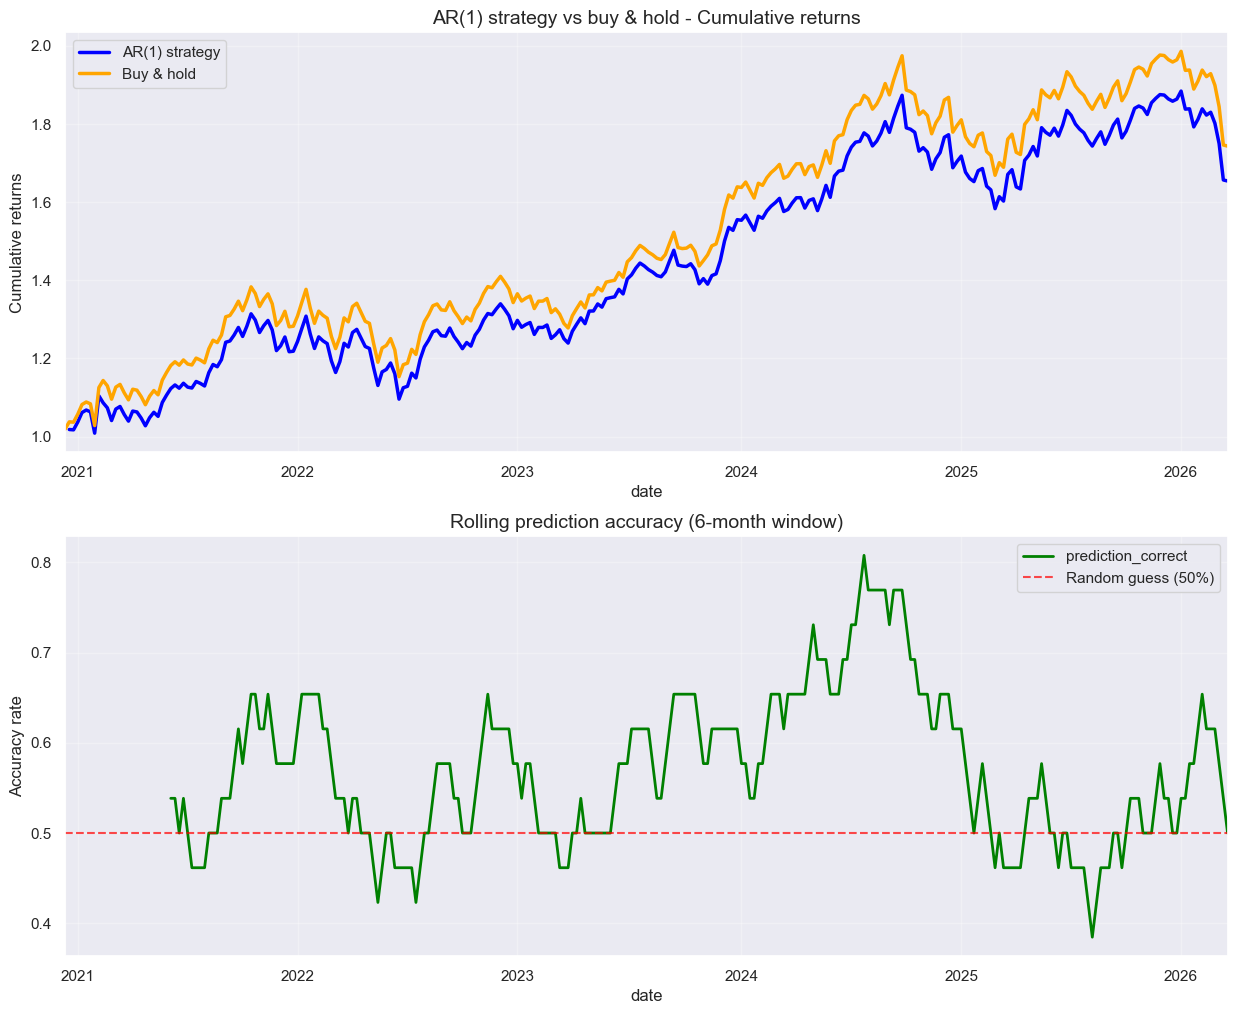

In [27]:
# Visualize the strategy performance
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Cumulative returns comparison
strategy_cumret = (1 + ar_strategy['strategy_returns'].dropna()).cumprod()
buyhold_cumret = (1 + ar_strategy['actual_returns'].dropna()).cumprod()

strategy_cumret.plot(ax=ax1, label='AR(1) strategy', linewidth=2.5, color='blue')
buyhold_cumret.plot(ax=ax1, label='Buy & hold', linewidth=2.5, color='orange')
ax1.set_title('AR(1) strategy vs buy & hold - Cumulative returns', fontsize=14)
ax1.set_ylabel('Cumulative returns')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prediction accuracy
ar_strategy['prediction_correct'] = (
    (ar_strategy['predicted_returns'] > 0) & (ar_strategy['actual_returns'] > 0)
) | (
    (ar_strategy['predicted_returns'] < 0) & (ar_strategy['actual_returns'] < 0)
)

# Rolling prediction accuracy (6-month window)
rolling_accuracy = ar_strategy['prediction_correct'].rolling(26).mean()
rolling_accuracy.plot(ax=ax2, color='green', linewidth=2)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Random guess (50%)')
ax2.set_title('Rolling prediction accuracy (6-month window)', fontsize=14)
ax2.set_ylabel('Accuracy rate')
ax2.legend()
ax2.grid(True, alpha=0.3)
